In [19]:
import sys
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import scipy.signal as signal
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader,TensorDataset,random_split,SubsetRandomSampler, ConcatDataset
from torchvision import transforms 

sys.path.append('D:/ppg_project/code/model_build/my_tool/model')
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool')
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool/data_load')

from Gan_base_1D import PPG_GAN_1D
# from lstm_unet import lstm_unet 
# from model_builder import k_fold_training 
from performance import performance
from ppg_labeled_load import PPGDataset

<>:9: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:9: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\Admin\AppData\Local\Temp\ipykernel_11188\735757751.py:9: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = {"Case":["PAC","PVC","PAC-nhip-doi","PAC-cap-doi","PVC-nhip-doi","PVC-cap-doi"],"Group": True})


254
torch.Size([1, 800])


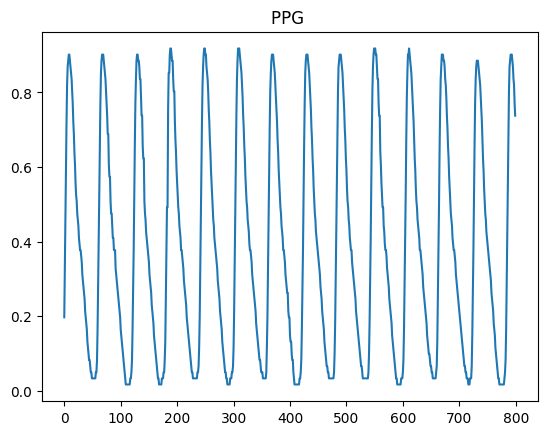

 device : cpu


In [20]:
# Hyperparameters 
NUM_EPOCHS = 1000
BATCH_SIZE = 64
LR_G = 0.0002       # Learning Rate Generator
LR_D = 0.0002       # Learning Rate Discriminator
BETA1 = 0.5         # Tham số Adam 

# Load
dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = {"Case":["PAC","PVC","PAC-nhip-doi","PAC-cap-doi","PVC-nhip-doi","PVC-cap-doi"],"Group": True})
print(dataset.count)


transform = transforms.Compose([
    transforms.ToTensor(),       # (0-255) thành (0.0-1.0)
    transforms.Normalize((0.5,), (0.5,)) # (0.0-1.0) thành (-1.0-1.0)
])


# DataLoader
train_loader = DataLoader(dataset=dataset, 
                          batch_size=BATCH_SIZE,
                          num_workers=0,
                          shuffle=True)


print(dataset[111][0].shape)
for i in [22]:
    plt.plot(dataset[i][0].numpy().flatten())
  
plt.title("PPG ")
plt.show()


if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f" device : {device}")

In [21]:

try:
    SIGNAL_LENGTH = dataset[0][0].shape[1]
except:
    SIGNAL_LENGTH = 800 
print(f" SIGNAL_LENGTH : {SIGNAL_LENGTH}")

para = {
     "z_dim": SIGNAL_LENGTH,           
     "dis_input_length": SIGNAL_LENGTH, 
     "dis_output_classes": 1
   
}

# Model 
model = PPG_GAN_1D(config=para).to(device)
model.print_structure('all')

criterion = nn.BCEWithLogitsLoss()
optimizer_g = optim.Adam(model.generator.parameters(), lr=LR_G, betas=(BETA1, 0.999))
optimizer_d = optim.Adam(model.discriminator.parameters(), lr=LR_D, betas=(BETA1, 0.999))

# GAN lặp lại
real_label_val = 0.9 
fake_label_val = 0.1 
z_dim = model.z_dim

print("\n GAN............")
for epoch in range(NUM_EPOCHS):
    loss_g_epoch = 0.0
    loss_d_epoch = 0.0
    
    for batch_idx, (real_signals, _) in enumerate(train_loader): 
        
        #  [B, 1, L]
        if real_signals.dim() == 2:
             real_signals = real_signals.unsqueeze(1)
        
        real_signals = real_signals.to(device)
        batch_size = real_signals.size(0)

      
        labels_real = torch.full((batch_size, 1), real_label_val, dtype=torch.float, device=device)
        labels_fake = torch.full((batch_size, 1), fake_label_val, dtype=torch.float, device=device)

        model.discriminator.zero_grad()
        output_real = model.forward_discriminator(real_signals)
        loss_d_real = criterion(output_real, labels_real)
        loss_d_real.backward() 

        z = torch.randn(batch_size, z_dim).to(device)
        fake_signals = model.forward_generator(z)
    
        output_fake = model.forward_discriminator(fake_signals.detach())
        loss_d_fake = criterion(output_fake, labels_fake)
        loss_d_fake.backward() 
        optimizer_d.step()

        # Generator 
        model.generator.zero_grad()
        output_g = model.forward_discriminator(fake_signals)
        loss_g = criterion(output_g, labels_real) 
        loss_g.backward()
        optimizer_g.step() 

        loss_d_epoch += (loss_d_real + loss_d_fake).item()
        loss_g_epoch += loss_g.item()

    # In loss
    avg_loss_d = loss_d_epoch / len(train_loader)
    avg_loss_g = loss_g_epoch / len(train_loader)
    print(f'*** EPOCH {epoch+1}/{NUM_EPOCHS} *** | Avg Loss D: {avg_loss_d:.4f} | Avg Loss G: {avg_loss_g:.4f}')



 SIGNAL_LENGTH : 800

--- Generator Config ---
{'z_dim': 800,
 'gen_input_channels': 1,
 'gen_activation': 'ReLU',
 'gen_filters': {'short': (80, 5, 2), 'middle': (40, 21, 10), 'long': (20, 61, 30)},
 'gen_total_filter': {'total': (50, 15, 7)},
 'gen_final_convs': [(50, 4, 1, 'Tanh'), (1, 2, 1, 'Tanh')]}

--Discriminator Config ---
{'dis_input_length': 800,
 'dis_activation': 'LeakyReLU',
 'dis_channels': [1, 64, 128, 256, 512, 1],
 'dis_kernels': [4, 4, 4, 4, 8],
 'dis_strides': [2, 2, 2, 2, 1],
 'dis_paddings': [1, 1, 1, 1, 0],
 'dis_output_classes': 1}

 GAN............
*** EPOCH 1/1000 *** | Avg Loss D: 1.5006 | Avg Loss G: 0.4731
*** EPOCH 2/1000 *** | Avg Loss D: 1.4784 | Avg Loss G: 0.4791
*** EPOCH 3/1000 *** | Avg Loss D: 1.4641 | Avg Loss G: 0.4846
*** EPOCH 4/1000 *** | Avg Loss D: 1.4532 | Avg Loss G: 0.4895
*** EPOCH 5/1000 *** | Avg Loss D: 1.4470 | Avg Loss G: 0.4952
*** EPOCH 6/1000 *** | Avg Loss D: 1.4350 | Avg Loss G: 0.5031
*** EPOCH 7/1000 *** | Avg Loss D: 1.4251 

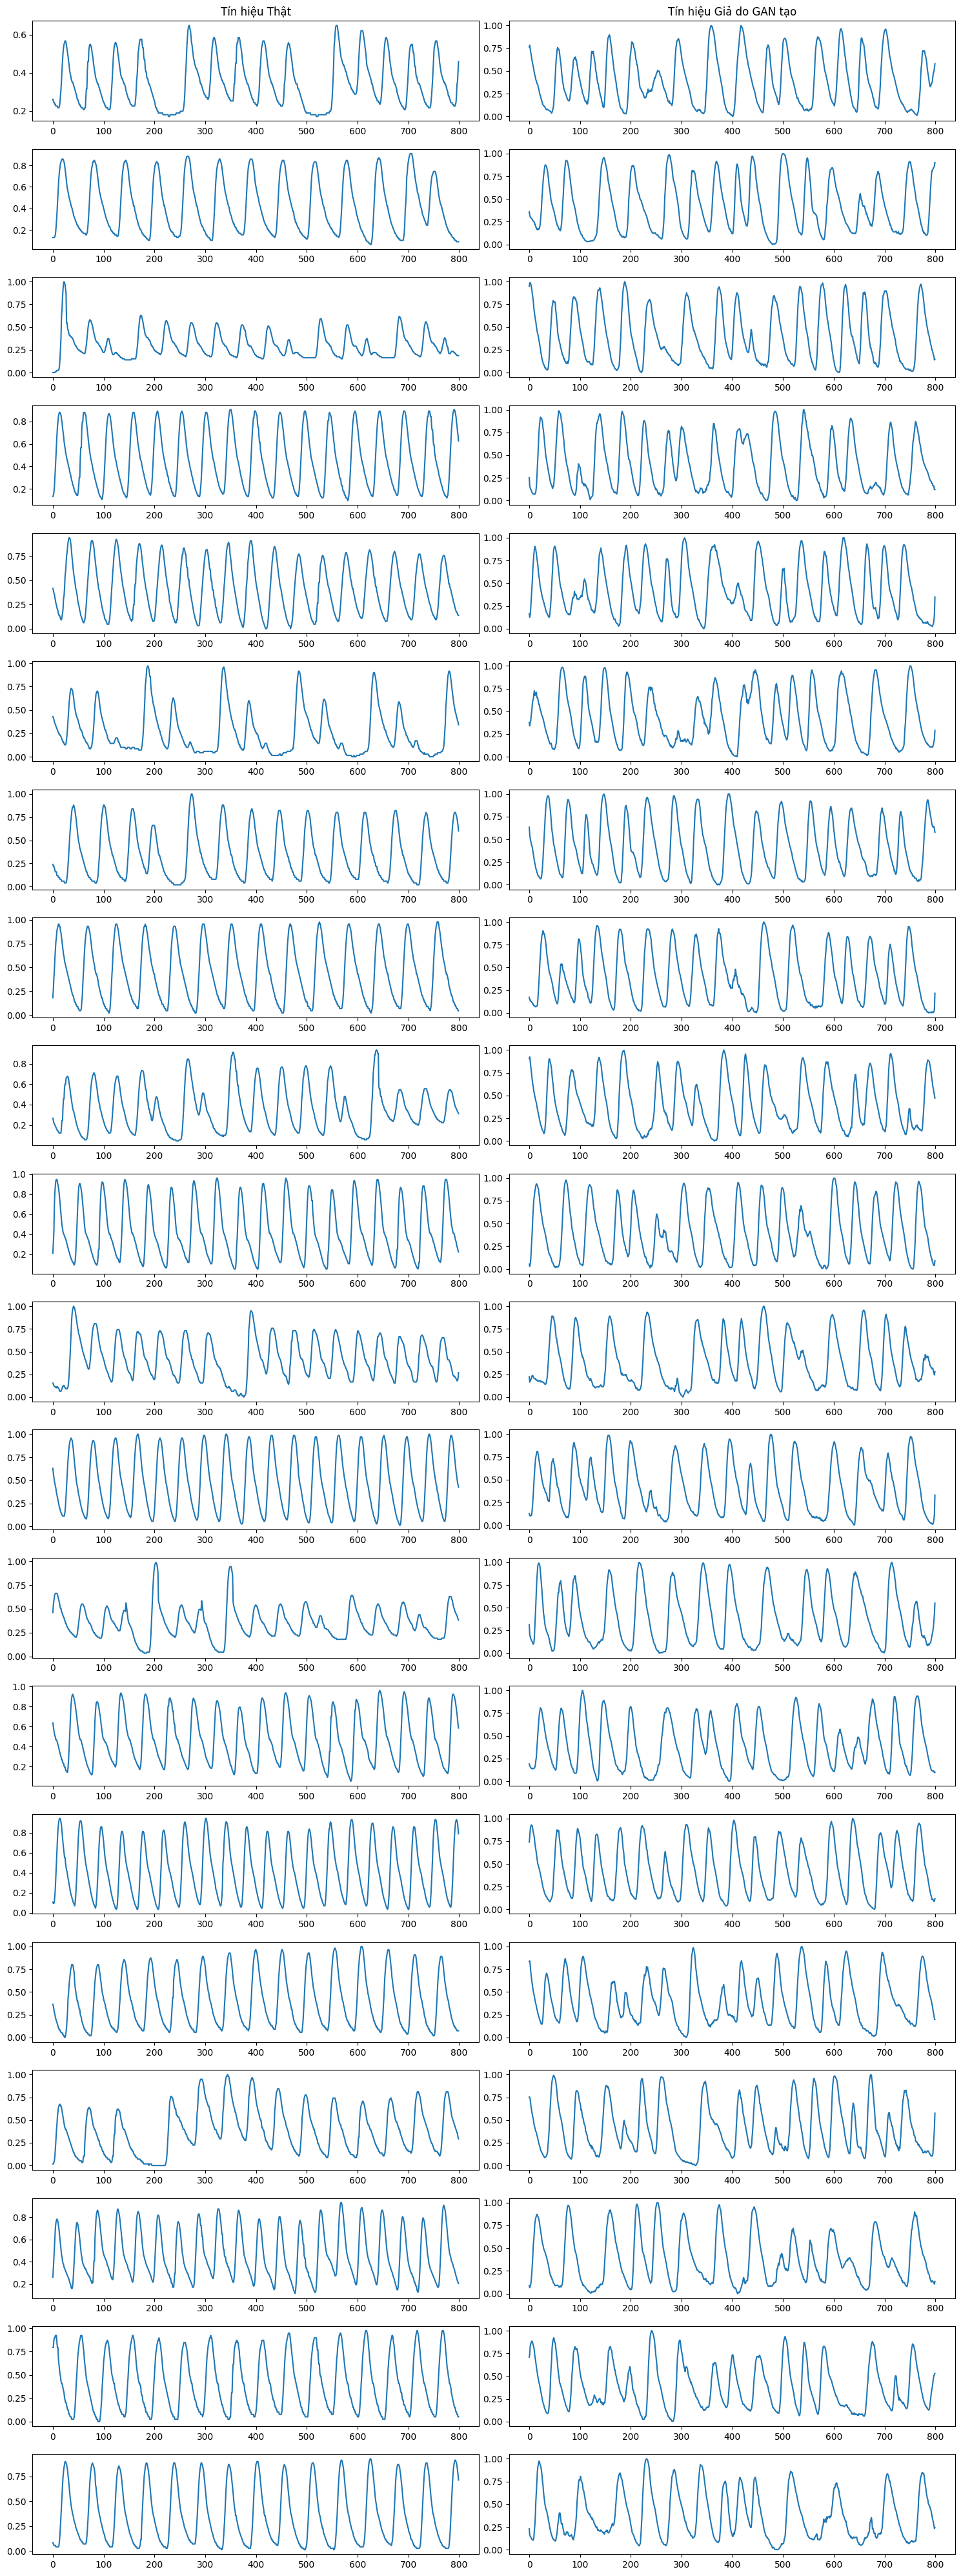

In [ ]:
      
# Lấy 20 mẫu 
z_test = torch.randn(20, z_dim).to(device) 

with torch.no_grad():
    model.eval() 
    fake_signals_test = model.forward_generator(z_test).cpu()
    model.train() 

real_signals_test, _ = next(iter(train_loader))
fig, axes = plt.subplots(20, 2, figsize=(15, 40)) 
axes[0, 0].set_title("Tín hiệu Thật")
axes[0, 1].set_title("Tín hiệu Giả do GAN tạo")


for i in range(20):
    axes[i, 0].plot(real_signals_test[i].numpy().flatten())
    axes[i, 1].plot(fake_signals_test[i].numpy().flatten())


plt.tight_layout()
plt.show()

real_signals 254 & 5000 fake_signals


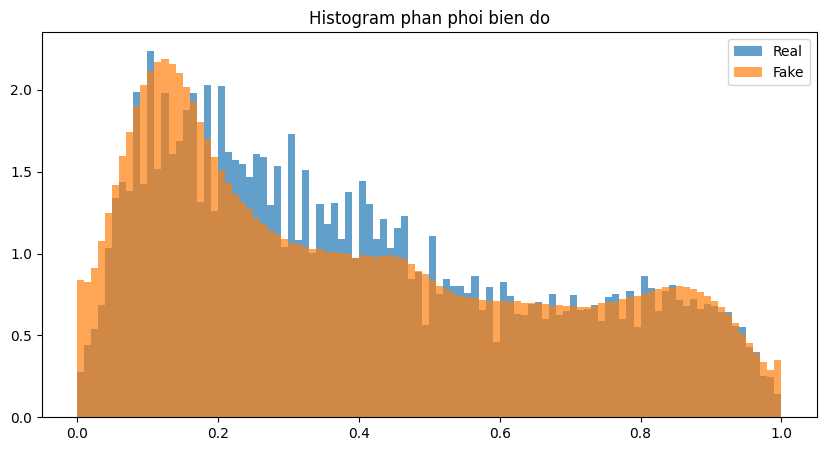

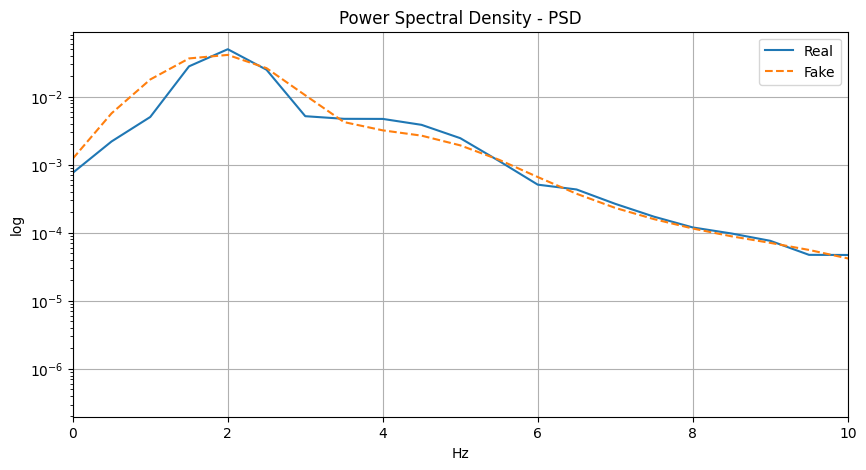

In [24]:
import scipy.signal as signal
import matplotlib.pyplot as plt
import numpy as np


NUM_TEST_SAMPLES = 5000
z_test_stats = torch.randn(NUM_TEST_SAMPLES, z_dim).to(device)

with torch.no_grad():
    model.eval()
    fake_signals_stats = model.forward_generator(z_test_stats).cpu().numpy()
    model.train()

test_loader_stats = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
real_signals_stats = []
for i, (real_batch, _) in enumerate(test_loader_stats):
    real_signals_stats.append(real_batch.numpy())
    if len(real_signals_stats) * BATCH_SIZE >= NUM_TEST_SAMPLES:
        break
real_signals_stats = np.concatenate(real_signals_stats, axis=0)

print(f"real_signals {real_signals_stats.shape[0]} & {fake_signals_stats.shape[0]} fake_signals")

# Histogram
plt.figure(figsize=(10, 5))
plt.title("Histogram phan phoi bien do")
# flatten() 
plt.hist(real_signals_stats.flatten(), bins=100, alpha=0.7, label='Real', density=True)
plt.hist(fake_signals_stats.flatten(), bins=100, alpha=0.7, label='Fake', density=True)
plt.legend()
plt.show()

fs = 100

freqs_real, psd_real = signal.welch(real_signals_stats, fs=fs, nperseg=fs*2, axis=-1)
psd_real_mean = np.mean(psd_real, axis=0).flatten()

freqs_fake, psd_fake = signal.welch(fake_signals_stats, fs=fs, nperseg=fs*2, axis=-1)
psd_fake_mean = np.mean(psd_fake, axis=0).flatten()

# PSD
plt.figure(figsize=(10, 5))
plt.title("Power Spectral Density - PSD")
plt.semilogy(freqs_real, psd_real_mean, label='Real')
plt.semilogy(freqs_fake, psd_fake_mean, label='Fake', linestyle='--')
plt.xlabel('Hz')
plt.ylabel('log')
plt.xlim(0, 10)
plt.legend()
plt.grid(True)
plt.show()